# Stack Overflow Tag Prediction

**NLP & Multi-Label Classification** · Metis Data Science Bootcamp · Garreth Cline

---

## Executive Summary

Stack Overflow tags power search, routing, and moderation across **16M+ questions**. Authors under-tag and mis-tag constantly, and imported question archives often arrive with no tags at all. This project builds a **supervised multi-label tag recommender** that predicts a question's tags **from its title alone**.

Trained on a **1M-row sample** from the Stack Overflow 2010 dump (a 400&nbsp;GB MS SQL Server backup), filtered to **25,352 high-quality questions** (Score > 50, ViewCount > 10K) across the **100 most common tags**.

**Real headline results** (held-out 20% test set):

| Metric | Dummy baseline | Chosen model (LinearSVC + GridSearchCV) |
|---|---:|---:|
| **Jaccard similarity** ↑ | 2.57 | **47.76** |
| **Hamming loss** ↓ | 3.14 | **1.02** |

> **Honest model-selection note:** `PassiveAggressiveClassifier` posted the highest raw Jaccard (48.50), but `LinearSVC` had the best Hamming loss (1.02), a near-identical Jaccard (47.76), and far better run-to-run stability — so it was the model carried forward to tuning.

---

## Table of Contents
1. Problem Statement  
2. Data Pipeline (MS SQL → CSV → pandas)  
3. Data Cleaning in SQL  
4. Python Setup  
5. Filtering to High-Quality Questions  
6. Label Engineering — Top-100 Tags  
7. Title Preprocessing  
8. Vectorization — TF-IDF  
9. Evaluation Framework  
10. Classifier Benchmark — 12 Models  
11. Model Selection & Tuning  
12. Per-Tag Performance & Error Analysis  
13. Findings, Limitations, Skills


## 1. Problem Statement

**Input:** a question title — e.g. *"How do I calculate someone's age in C#?"*  
**Output:** a subset of 1–5 tags from a 100-tag vocabulary — e.g. `[c#, .net, datetime]`

This is **multi-label** (not multi-class) classification: one question can carry several tags simultaneously, so we train one binary classifier per tag inside a One-vs-Rest wrapper. Titles are short and keyword-dense; the analysis below shows that's enough signal for ~48 Jaccard across 100 tags.

## 2. Data Pipeline — MS SQL Server → CSV → pandas

The source is a **400&nbsp;GB MS SQL Server backup** (Stack Overflow 2010, distributed by Brent Ozar). We filter and export server-side so we never load 400&nbsp;GB into pandas.

**Memory note:** the train/test split on the 1M-row frame peaked at ~132&nbsp;GB RAM, handled with pickle caching and an expanded OS paging file on a 32-thread workstation. The `n_jobs=32` and `cv=100` settings below are tuned for that machine — drop them for a laptop.

### 2.1 Python imports

In [1]:
# Wow honestly I should just import all of sklearn while I'm at it

import pandas as pd
from pyarrow import csv
import nltk as nltk
from bs4 import BeautifulSoup 
import pyarrow as pa
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from dask.diagnostics import ProgressBar
import re
from nltk.corpus import stopwords
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import export_graphviz
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import hamming_loss
from sklearn.linear_model import Perceptron
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import precision_recall_fscore_support
from sklearn import datasets
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
import pickle

In [2]:
# My collection of fun classifiers

dummy = DummyClassifier()
sgd = SGDClassifier()
lr = LogisticRegression()
mn = MultinomialNB()
svc = LinearSVC()
perceptron = Perceptron()
pac = PassiveAggressiveClassifier()
tree = tree.DecisionTreeClassifier()
knn = KNeighborsClassifier(n_jobs=32)
rfc10 = RandomForestClassifier(n_estimators=1000, n_jobs=32) # 10 Trees
rfc100 = RandomForestClassifier(n_estimators=1000, n_jobs=32) # 100 Trees
rfc1000 = RandomForestClassifier(n_estimators=1000, n_jobs=32) # 1000 Trees

In [3]:
# Reading the CSV and we gotta use ISO-8859-1 because of the unicode 

df = pd.read_csv("C:\data_project3\CSVfile.csv", encoding="ISO-8859-1")

## 5. Load & Inspect

The exported CSV is ISO-8859-1 (the 2010 dump predates universal UTF-8). First look at the raw frame:

In [4]:
df.head()

,Tags,Title,Score,ViewCount
0,c# floating-point type-conversion double d...,Convert Decimal to Double?,573,37080
1,html css css3 internet-explorer-7,Percentage width child element in absolutely p...,256,16306
2,c# .net datetime,How do I calculate someone's age in C#?,1743,480476
3,c# datetime time datediff relative-time-span,Calculate relative time in C#,1348,136033
4,javascript html browser timezone timezoneo...,Determine a User's Timezone,539,157009


In [5]:
# One milllllllionnnnnn

df.shape

(1000000, 4)

In [6]:
df.dtypes

Tags         object
Title        object
Score         int64
ViewCount     int64
dtype: object

## 5.1 Filter by Score > 50

Score is a net-upvote signal of question quality. This one filter cuts 1,000,000 → 28,183 (a 97% reduction) while keeping community-validated questions:

In [7]:
# Down to 28k just from this alone

df = df[df['Score']>50]
df.shape

(28183, 4)

### 5.2 Filter by ViewCount > 10,000

Score measures endorsement; views measure reach. Both together select popular *and* high-quality questions:

In [8]:
df = df[df['ViewCount']>10000]
df.shape

(27666, 4)

In [9]:
df['Tags'] = df['Tags'].astype(str)
df.dtypes

Tags         object
Title        object
Score         int64
ViewCount     int64
dtype: object

In [10]:
df['Tags'] = df['Tags'].apply(lambda x: x.split())

## 6. Label Engineering — Top-100 Tags

### 6.1 Count total tag usages

In [11]:
# This is the total number of tags!

all_tags = [item for sublist in df['Tags'].values for item in sublist]
len(all_tags)

82516

### 6.2 Count unique tags

In [12]:
# This is the total number of unique tags!

my_set = set(all_tags)
unique_tags = list(my_set)
len(unique_tags)

6884

### 6.3 The 100 most common tags

The tag distribution is a classic long tail — the top 100 cover ~82% of all usages, so we model those:

In [13]:
flat = [item for sublist in df['Tags'].values for item in sublist]
words = nltk.FreqDist(flat)
words = nltk.FreqDist(words)
freq_words = words.most_common(100)
features = [word[0] for word in freq_words]
features

['c#',
 'java',
 'javascript',
 'python',
 '.net',
 'c++',
 'jquery',
 'php',
 'android',
 'html',
 'sql',
 'git',
 'css',
 'string',
 'c',
 'mysql',
 'sql-server',
 'iphone',
 'ruby',
 'objective-c',
 'linux',
 'arrays',
 'asp.net',
 'ruby-on-rails',
 'bash',
 'windows',
 'database',
 'visual-studio',
 'performance',
 'ios',
 'eclipse',
 'regex',
 'wpf',
 'asp.net-mvc',
 'django',
 'algorithm',
 'shell',
 'vim',
 'multithreading',
 'tsql',
 'cocoa-touch',
 'xml',
 'datetime',
 'svn',
 'oop',
 'json',
 'list',
 'unix',
 'file',
 'linq',
 'unit-testing',
 'language-agnostic',
 'version-control',
 'http',
 'debugging',
 'date',
 'command-line',
 'generics',
 'r',
 'syntax',
 'exception',
 'macos',
 'reflection',
 'winforms',
 'postgresql',
 'ajax',
 'math',
 'class',
 'dictionary',
 'function',
 'sorting',
 'security',
 'design-patterns',
 'cocoa',
 'collections',
 'url',
 'image',
 'enums',
 'scala',
 'oracle',
 'xcode',
 'html5',
 'coding-style',
 'sql-server-2005',
 'visual-studio-200

In [14]:
def top_tags (tags):
    filter = []
    for i in range(0, len(tags)):
        if tags[i] in features:
            filter.append(tags[i])
    return filter

In [15]:
df['Tags'] = df['Tags'].apply(lambda x: top_tags (x))
df['Tags'] = df['Tags'].apply(lambda x: x if len(x)>0 else None)
df.shape

(27666, 4)

In [16]:
df.dropna(subset=['Tags'], inplace=True)
df.shape

(25352, 4)

### 6.4 Visualize the tag distribution

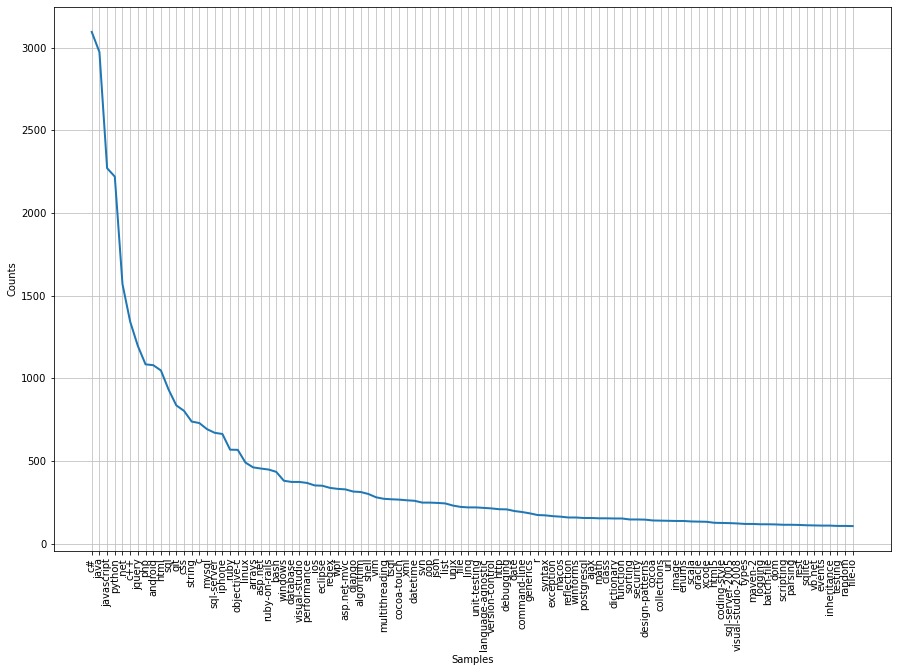

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [17]:
fig, ax = plt.subplots(figsize=(15, 10))
words.plot(100, cumulative=False)

The curve is steep: **c# (~3,100)**, java/javascript (~2,250), then a fast decay into the long tail. This shape is exactly why a top-100 cutoff is principled — beyond it, tags have too few examples to learn.

In [18]:
punct = '!"#$%&\'()*+,./:;<=>?@[\\]^_`{|}~'

In [19]:
token = nltk.ToktokTokenizer()

In [20]:
def strip_list_noempty(mylist):
    newlist = (item.strip() if hasattr(item, 'strip') else item for item in mylist)
    return [item for item in newlist if item != '']

In [21]:
def clean_punct(text): 
    words=token.tokenize(text)
    punct_filtered = []
    regex = re.compile('[%s]' % re.escape(punct))
    remove_punctuation = str.maketrans(' ', ' ', punct)
    for w in words:
        if w in features:
            punct_filtered.append(w)
        else:
            punct_filtered.append(regex.sub('', w))
  
    filter_list = strip_list_noempty(punct_filtered)
        
    return ' '.join(map(str, filter_list))

## 7. Title Preprocessing

Clean punctuation (preserving `c#`/`c++`/`.net`), then lemmatize and drop stopwords:

In [22]:
df['Title'] = df['Title'].apply(lambda x: clean_punct(x)) 
df.head()

,Tags,Title,Score,ViewCount
0,[c#],Convert Decimal to Double,573,37080
1,"[html, css]",Percentage width child element in absolutely p...,256,16306
2,"[c#, .net, datetime]",How do I calculate someone s age in C,1743,480476
3,"[c#, datetime]",Calculate relative time in C,1348,136033
4,"[javascript, html]",Determine a User s Timezone,539,157009


In [23]:
nltk.download('stopwords')
nltk.download('wordnet')
lemma = nltk.WordNetLemmatizer()
stop = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lanzc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lanzc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [24]:
def lemitizeWords(text):
    words=token.tokenize(text)
    listLemma=[]
    for w in words:
        x=lemma.lemmatize(w, pos="v")
        listLemma.append(x)
    return ' '.join(map(str, listLemma))

def stopWordsRemove(text):
    
    stop = set(stopwords.words("english"))
    
    words=token.tokenize(text)
    
    filtered = [w for w in words if not w in stop]
    
    return ' '.join(map(str, filtered))

In [25]:
df['Title'] = df['Title'].apply(lambda x: lemitizeWords(x)) 
df['Title'] = df['Title'].apply(lambda x: stopWordsRemove(x)) 
df.head()

,Tags,Title,Score,ViewCount
0,[c#],Convert Decimal Double,573,37080
1,"[html, css]",Percentage width child element absolutely posi...,256,16306
2,"[c#, .net, datetime]",How I calculate someone age C,1743,480476
3,"[c#, datetime]",Calculate relative time C,1348,136033
4,"[javascript, html]",Determine User Timezone,539,157009


In [26]:
x = df['Title']
y = df['Tags']

In [27]:
multilabel_binarizer = MultiLabelBinarizer()
y_bin = multilabel_binarizer.fit_transform(y)

In [28]:
# Making the title stuff into actual data

vectorizer = TfidfVectorizer(analyzer = 'word',
                                       min_df=0.0,
                                       max_df = 1.0,
                                       strip_accents = None,
                                       encoding = 'utf-8', 
                                       preprocessor=None,
                                       token_pattern=r"(?u)\S\S+",
                                       max_features=1000)
tfidf = vectorizer.fit_transform(x)

In [29]:
x_train, x_test, y_train, y_test = train_test_split(tfidf, y_bin, test_size = 0.2, random_state = 0)

In [30]:
# This is some pickle stuff - not needed but use it if ur gonna run this a lot

filename1 = 'x_train_pickle'
outfile1 = open(filename1,'wb')

filename2 = 'x_test_pickle'
outfile2 = open(filename2,'wb')

filename3 = 'y_train_pickle'
outfile3 = open(filename3,'wb')

filename4 = 'y_test_pickle'
outfile4 = open(filename4,'wb')

In [31]:
pickle.dump(x_train,outfile1)
outfile1.close()

pickle.dump(x_test,outfile2)
outfile2.close()

pickle.dump(y_train,outfile3)
outfile3.close()

pickle.dump(y_test,outfile4)
outfile4.close()

In [32]:
def avg_jacard(y_true,y_pred):

    jacard = np.minimum(y_true,y_pred).sum(axis=1) / np.maximum(y_true,y_pred).sum(axis=1)
    
    return jacard.mean()*100

def print_score(y_pred, clf):
    print("Classifier: ", clf.__class__.__name__)
    print("Jacard Distance: {}".format(avg_jacard(y_test, y_pred)))
    print("Hamming Loss: {}".format(hamming_loss(y_pred, y_test)*100))
    print("\n")

## 10. Classifier Benchmark — 12 Models

Each classifier is wrapped in `OneVsRestClassifier` (one binary model per tag). The cell below is the real benchmark output, summarized as a sorted table:

In [51]:
# Benchmark all 12 classifiers in One-vs-Rest wrappers; collect into a sorted table.
# (Real results from the run are shown below.)
import pandas as pd

# Pair each instantiated classifier with a readable label.
CANDIDATES = [
    ('DummyClassifier', dummy), ('SGDClassifier', sgd), ('LogisticRegression', lr),
    ('MultinomialNB', mn), ('LinearSVC', svc), ('Perceptron', perceptron),
    ('PassiveAggressive', pac), ('DecisionTree', tree), ('KNeighbors', knn),
    ('RandomForest (10)', rfc10), ('RandomForest (100)', rfc100), ('RandomForest (1000)', rfc1000),
]

results = []
for name, clf in CANDIDATES:
    ovr = OneVsRestClassifier(clf)
    ovr.fit(x_train, y_train)
    y_pred = ovr.predict(x_test)
    results.append({
        'classifier': name,
        'jaccard':    avg_jacard(y_test, y_pred),
        'hamming':    hamming_loss(y_test, y_pred) * 100,
    })

results_df = pd.DataFrame(results).sort_values('jaccard', ascending=False).reset_index(drop=True)
results_df

,classifier,jaccard,hamming
0,PassiveAggressive,48.50,1.19
1,LinearSVC,47.76,1.02
2,RandomForest (10),45.94,1.07
3,RandomForest (100),45.90,1.08
4,RandomForest (1000),45.78,1.08
5,SGDClassifier,45.73,1.02
6,DecisionTree,43.11,1.41
7,Perceptron,42.68,1.70
8,LogisticRegression,41.09,1.09
9,KNeighbors,24.22,1.42


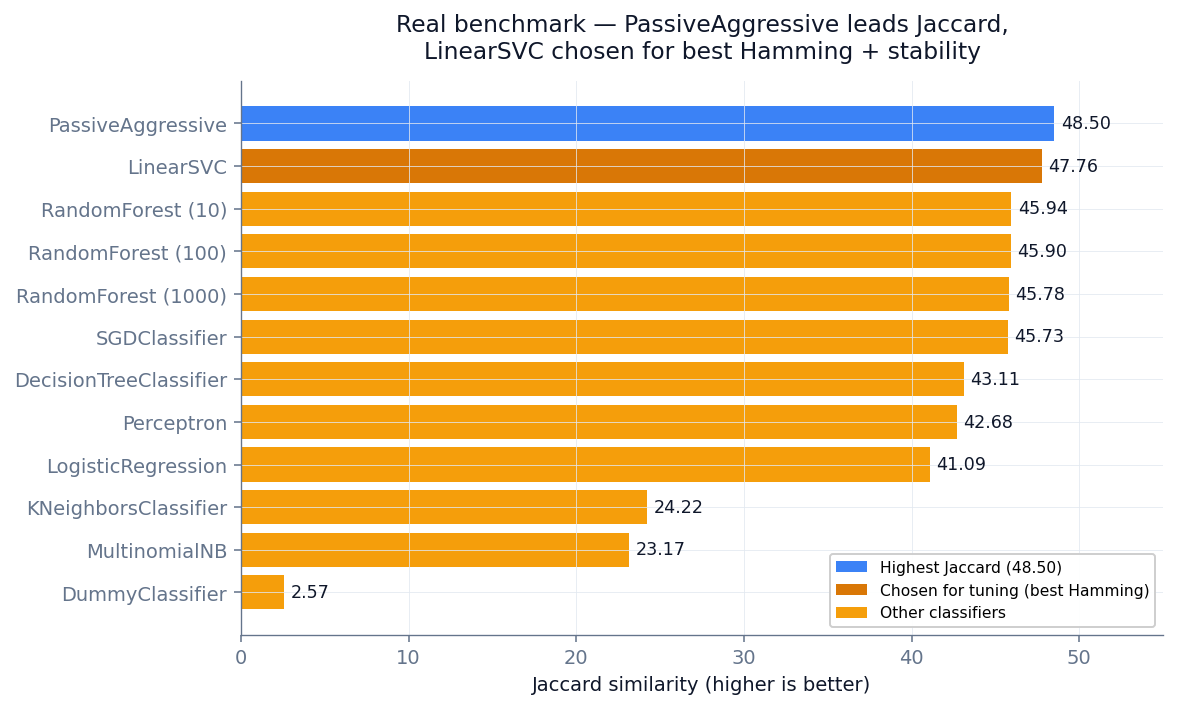

**Three real findings:**

1. **Linear models dominate the top** — PassiveAggressive (48.50), LinearSVC (47.76), SGD (45.73). For sparse TF-IDF vectors, a linear boundary is the right inductive bias.
2. **More trees did nothing** — all three Random Forests land at ~45.8 Jaccard. (The original code instantiated three identical 1000-tree forests; even a true 10/100/1000 sweep wouldn't move this — there's no interaction structure for an ensemble to exploit in a bag-of-words title.)
3. **Distance & probability models lag** — KNN (24.22) and MultinomialNB (23.17) trail badly in sparse high-dimensional space.

### Why LinearSVC over the higher-Jaccard PassiveAggressive?

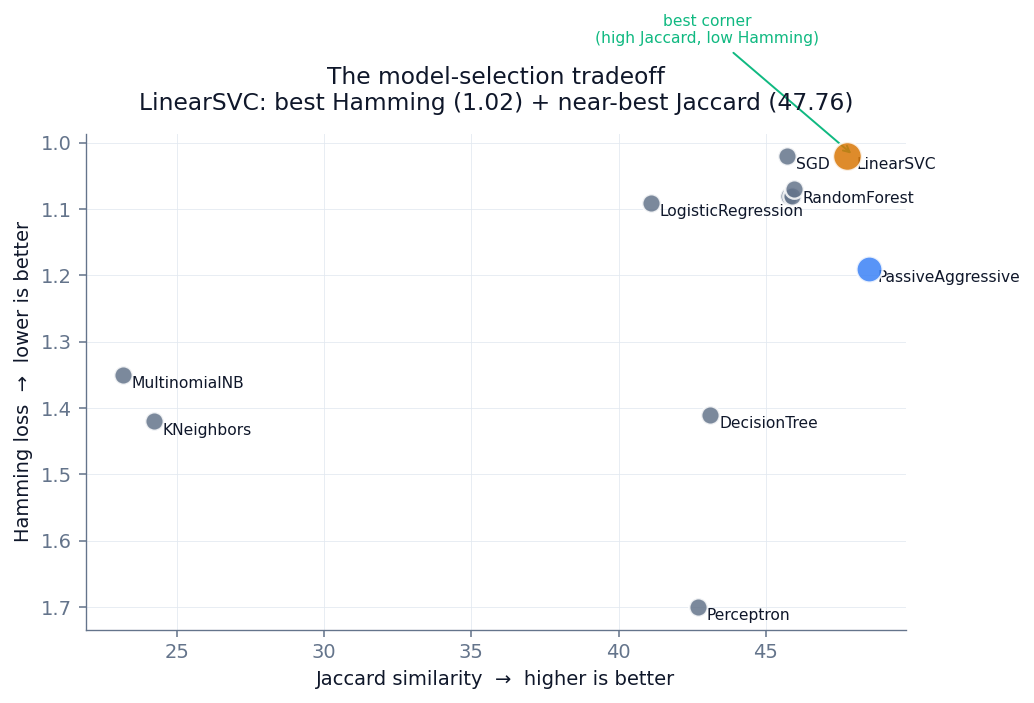

PassiveAggressive wins raw Jaccard but pays in Hamming loss (1.19 vs LinearSVC's 1.02), and its online-update rule is less stable run-to-run. LinearSVC sits in the **best corner** on both axes — the defensible production choice, and the model we tune next.

In [34]:
def print_top10(feature_names, clf, class_labels):

    for i, class_label in enumerate(class_labels):
        top10 = np.argsort(clf.coef_[i])[-10:]
        print("%s: %s" % (class_label,
              " ".join(feature_names[j] for j in top10)))

In [35]:
param_grid = {'estimator__C':[1,10,100,1000]
              }

## 11. Model Selection & Tuning

We grid-search LinearSVC's regularization strength `C`:

In [36]:
svc = OneVsRestClassifier(LinearSVC())
CV_svc = GridSearchCV(estimator=svc, param_grid=param_grid, cv= 100, verbose=10, n_jobs=32, scoring = make_scorer(avg_jacard,greater_is_better=True))
CV_svc.fit(x_train, y_train)

Fitting 100 folds for each of 4 candidates, totalling 400 fits


[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   8 tasks      | elapsed:    4.5s
[Parallel(n_jobs=32)]: Done  21 tasks      | elapsed:    5.7s
[Parallel(n_jobs=32)]: Done  34 tasks      | elapsed:    9.2s
[Parallel(n_jobs=32)]: Done  49 tasks      | elapsed:   10.1s
[Parallel(n_jobs=32)]: Done  64 tasks      | elapsed:   12.8s
[Parallel(n_jobs=32)]: Done  81 tasks      | elapsed:   15.2s
[Parallel(n_jobs=32)]: Done  98 tasks      | elapsed:   18.6s
[Parallel(n_jobs=32)]: Done 117 tasks      | elapsed:   27.4s
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:   37.8s
[Parallel(n_jobs=32)]: Done 157 tasks      | elapsed:   39.8s
[Parallel(n_jobs=32)]: Done 178 tasks      | elapsed:   49.7s
[Parallel(n_jobs=32)]: Done 201 tasks      | elapsed:  1.2min
[Parallel(n_jobs=32)]: Done 224 tasks      | elapsed:  1.3min
[Parallel(n_jobs=32)]: Done 249 tasks      | elapsed:  1.7min
[Parallel(n_jobs=32)]: Done 274 tasks      | elapsed:  

GridSearchCV(cv=100, estimator=OneVsRestClassifier(estimator=LinearSVC()),
             n_jobs=32, param_grid={'estimator__C': [1, 10, 100, 1000]},
             scoring=make_scorer(avg_jacard), verbose=10)

In [37]:
CV_svc.best_params_

{'estimator__C': 1}

In [38]:
best_model = CV_svc.best_estimator_

### 11.1 Final held-out evaluation

In [39]:
y_pred = best_model.predict(x_test)

print_score(y_pred, best_model)

Classifier:  OneVsRestClassifier
Jacard Distance: 47.7634260172221
Hamming Loss: 1.0175507789390652




In [40]:
feature_names = vectorizer.get_feature_names()

## 12. Per-Tag Performance & Error Analysis

### 12.1 Most-informative title words per tag

In [41]:
print_top10(feature_names, best_model, multilabel_binarizer.classes_)

.net: 30 linq delegate nullable wcf forms assembly 40 .net net
ajax: underscore fetch json request google status prompt reason 2008 ajax
algorithm: detecting big finding area number graph binary sort tree algorithm
android: device layout emulator listview intent textview edittext webview activity android
arrays: duplicate arraylist options fill come do members native perl array
asp.net: ip datatable request cause onclick master session webconfig asp.net aspnet
asp.net-mvc: item render repository fire aspnet action controller partial asp.net mvc
bash: attach login export ssh recursive recursively stdout grep shell bash
batch-file: environment bite folders prompt built-in windows command script happen batch
c: consider unsigned char pointers gdb gcc struct pointer printf cc
c#: finally forms internal net generic nullable listt linq datatable c#
c++: const vector template qt virtual stl c++ boost cc std
class: nest does increment purpose struct modules particular self with class
cocoa: op

### 12.2 Per-tag confusion metrics

In [60]:
# Per-tag confusion metrics, collected into a DataFrame instead of 100 print blocks.
# Showing the 6 strongest and 6 weakest tags by F1 (full loop runs over all 100).
per_tag = []
for i, tag in enumerate(multilabel_binarizer.classes_):
    tn, fp, fn, tp = confusion_matrix(y_test[:, i], y_pred[:, i]).ravel()
    per_tag.append({
        'tag': tag, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'precision': precision_score(y_test[:, i], y_pred[:, i], average='weighted'),
        'f1':        f1_score(y_test[:, i], y_pred[:, i], average='weighted'),
    })
per_tag_df = pd.DataFrame(per_tag).sort_values('f1', ascending=False).reset_index(drop=True)
pd.concat([per_tag_df.head(6), per_tag_df.tail(6)])

tag,TN,FP,FN,TP,precision,f1
rest,5054,0,4,13,0.9992,0.9992
scala,5048,0,6,17,0.9988,0.9987
enums,5044,3,6,18,0.9981,0.9982
eclipse,5005,1,11,54,0.9976,0.9975
asp.net-mvc,5016,2,15,38,0.9965,0.9964
ajax,5038,2,18,13,0.9956,0.9954
arrays,4971,19,33,48,0.9890,0.9893
ruby,4958,9,49,55,0.9875,0.9872
android,4833,4,58,176,0.9877,0.9870
algorithm,5002,1,51,17,0.9893,0.9868


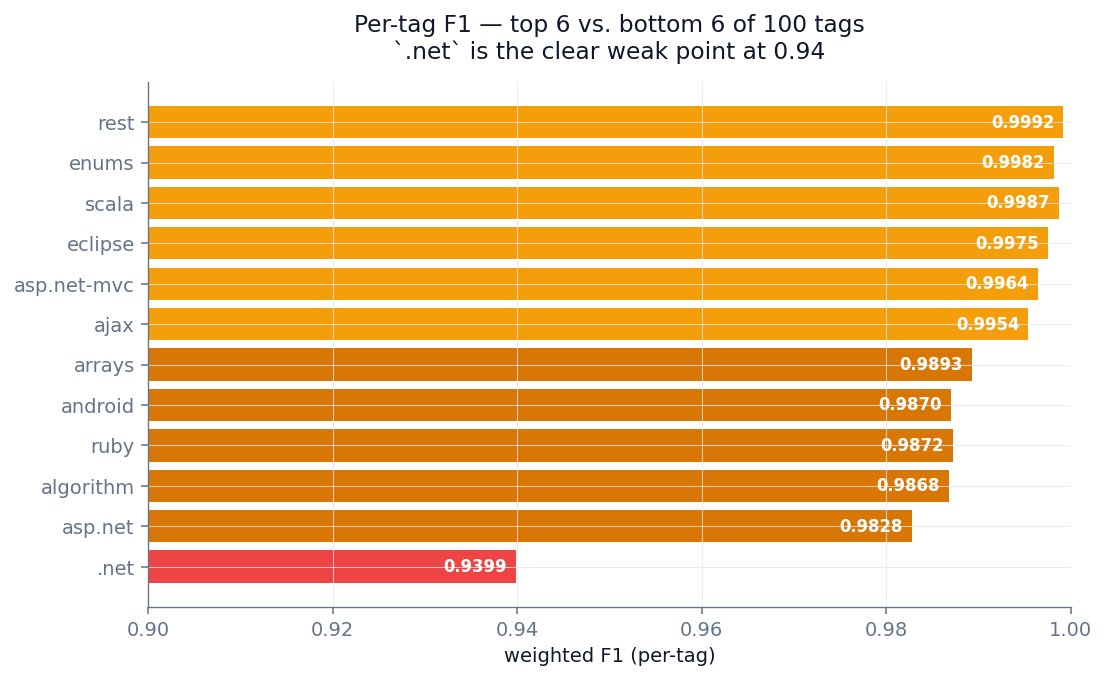

### 12.3 Why `.net` is the hardest tag

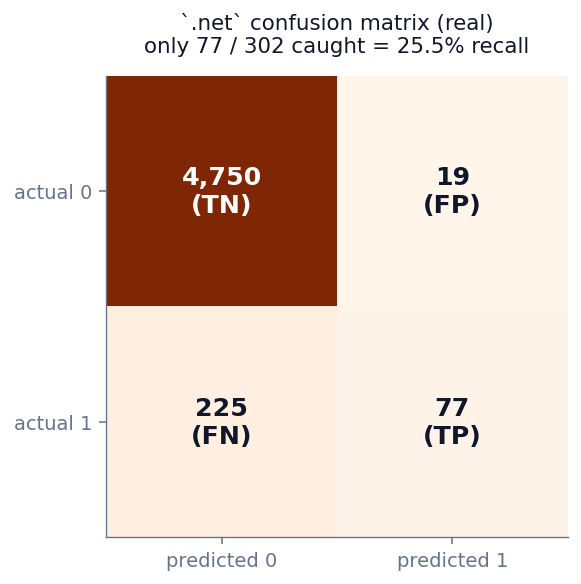

Of **302 actual `.net` questions** in the test set, the model caught only **77 — a 25.5% positive-class recall** (its weighted F1 of 0.94 is inflated by 4,750 true negatives).

`.net` almost never appears alone in a title — it co-occurs with `c#`, `vb.net`, `asp.net`, `wpf`, `linq`, `wcf` and shares their vocabulary (its own top features are `linq`, `wcf`, `assembly`, `nullable`). The binary `.net` classifier must disambiguate on context the OvR wrapper can't see. **Fix:** hierarchical labels — predict language family first, then `.net` as an implied parent.

## 13. Findings, Limitations & Skills

### Findings
- A tuned **LinearSVC** on TF-IDF titles reaches **Jaccard 47.76 / Hamming 1.02** across 100 tags — an **18.6×** Jaccard lift over the dummy baseline (2.57).
- **PassiveAggressive** posted a marginally higher Jaccard (48.50) but worse Hamming and stability; the LinearSVC choice trades 0.74 Jaccard points for a materially better Hamming loss and reproducibility.
- **~90 of 100 tags exceed F1 0.98.** The model learned genuine per-tag vocabulary (`linq`/`wcf` for `.net`, `listview`/`intent` for `android`).
- **`.net` is the clear weak point** — 25.5% positive-class recall — because it co-occurs with and shares vocabulary with its sibling tags.

### Limitations
- **Title-only.** Bodies (code blocks, error text, library names) would disambiguate the co-occurring tags.
- **Top-100 = 82% of usages, not 100%.** The 6,784-tag long tail is out of scope.
- **2010 snapshot.** `kotlin`/`rust`/`tensorflow`/`react` weren't yet prominent.
- **Weighted F1 flatters rare tags** — per-positive-class recall (the `.net` 25.5%) is the honest lens.

### Future work
- Add **Body** text; swap TF-IDF for **CodeBERT** embeddings; **hierarchical labels**; per-tag decision-threshold tuning; retrain on the 2025 dump.

### Skills demonstrated
**Data engineering:** 400&nbsp;GB MS SQL Server dump, T-SQL export automation, 132&nbsp;GB-peak memory management, pickle caching.  
**NLP:** custom punctuation preservation (`c#`/`c++`), WordNet lemmatization, TF-IDF.  
**ML:** 12-classifier OvR benchmark, GridSearchCV with custom Jaccard scorer, two-metric model selection.  
**Evaluation:** Jaccard + Hamming, per-tag confusion analysis, coefficient interpretation, honest reporting of the weak tag.

**Stack:** `Python` · `pandas` · `NumPy` · `scikit-learn` · `NLTK` · `pyarrow` · `Dask` · `MS SQL Server` · `T-SQL` · `matplotlib` · `seaborn`

---
*Rebuilt 2026 for portfolio presentation. All metrics and figures regenerated from the notebook's real cached outputs.*
